In [1]:
# set up the python
import cosima_cookbook as cc
from dask.distributed import Client
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import numpy as np
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import cmocean as cm
import cartopy.feature as cft
import cftime
import IPython.display
import sys, os, warnings
import matplotlib.animation as animation
from cartopy.mpl.geoaxes import GeoAxes  # Import GeoAxes for Cartopy plotting
from mpl_toolkits.axes_grid1 import AxesGrid
import gsw
from xgcm import Grid

In [2]:
client = Client(n_workers=28)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/35815/status,
Dashboard: /proxy/35815/status,Workers: 28
Total threads: 28,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40817,Workers: 28
Dashboard: /proxy/35815/status,Total threads: 28
Started: Just now,Total memory: 251.19 GiB
Comm: tcp://127.0.0.1:36205,Total threads: 1
Dashboard: /proxy/45703/status,Memory: 8.97 GiB
Nanny: tcp://127.0.0.1:40849,


2025-08-14 13:10:59,521 - distributed.nanny - WARNING - Restarting worker


In [3]:
session = cc.database.create_session()
db = '/g/data/x77/hm1221/CDW_changes/Jupyter_notebooks/RYF_perturbation.db'
session1 = cc.database.create_session(db)

In [4]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

In [5]:
# time period
start_time = '2140-01-01'
end_time = '2164-12-31'

In [6]:
# time period for map
start_time1 = '2160-01-01'
end_time1 = '2164-12-31'

start_time2 = '2151-12-01'
end_time2 = '2154-12-31'

In [7]:
#load T
temp_ctrl = cc.querying.getvar(expt='01deg_jra55v13_ryf9091', variable='temp', 
                          session=session1, frequency='1 monthly').sel(time = slice(start_time, end_time))
temp_th = cc.querying.getvar(expt='01deg_jra55v13_ryf9091_ssp585_th', variable='temp', 
                          session=session1, frequency='1 monthly').sel(time = slice(start_time, end_time))

[gadi-cpu-bdw-0084:2035722:0:2035722] Caught signal 11 (Segmentation fault: invalid permissions for mapped object at address 0x14a05ec19cb0)
malloc(): unsorted double linked list corrupted
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: User

In [8]:
# read practical salinity
salt_ctrl = cc.querying.getvar(expt='01deg_jra55v13_ryf9091', variable='salt', 
                          session=session1, frequency='1 monthly').sel(time = slice(start_time, end_time))

salt_th = cc.querying.getvar(expt='01deg_jra55v13_ryf9091_ssp585_th', variable='salt', 
                          session=session1, frequency='1 monthly').sel(time = slice(start_time, end_time))

/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks

In [9]:
shelf_mask = xr.open_dataarray('/scratch/x77/hm1221/nc_files/shelf_mask.nc')

st_ocean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/st_ocean.nc')

In [10]:
## Get shelf mask
x_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/x_shelf.txt')
y_shelf = np.loadtxt('/scratch/x77/hm1221/nc_files/y_shelf.txt')

In [11]:
bound_up_mean = xr.open_dataarray('/scratch/x77/hm1221/nc_files/bound_up_mean.nc')
bound_low_mean= xr.open_dataarray("/scratch/x77/hm1221/nc_files/bound_low_mean.nc")

In [12]:
# calculate the mean state
def temp_400m(temp):
    temp_400 = temp.sel(yt_ocean = slice(-90,-50)).sel(st_ocean = 400., method = 'nearest').load()
    temp_400_mean = temp_400.where(shelf_mask<0.8).load()
    temp_400_mean_5yr = temp_400.sel(time = slice(start_time1,end_time1)).mean('time').load()
    temp_400_mean =  temp_400_mean.mean(('xt_ocean','yt_ocean')).load()

    return [temp_400_mean_5yr,temp_400_mean]

In [13]:
temp_400_mean_ctrl_5yr,temp_400_mean_ctrl = temp_400m(temp_ctrl)

In [14]:
data = xr.Dataset({
    'Control': temp_400_mean_ctrl_5yr
})

In [15]:
# land mask
land = xr.where(np.isnan(temp_400_mean_ctrl_5yr[:,:].rename('land')), 1, np.nan)

In [16]:
def var_mean_5yr(var):
    var_mean_5yr_1 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time1,end_time1)).mean('time').load()
    var_mean_5yr_2 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time2,end_time2)).mean('time').load()
    var_mean_5yr_3 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time3,end_time3)).mean('time').load()
    var_mean_5yr_4 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time4,end_time4)).mean('time').load()
    var_mean_5yr_5 = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time5,end_time5)).mean('time').load()
    
    var_season = (var_mean_5yr_1+var_mean_5yr_2+var_mean_5yr_3+var_mean_5yr_4+var_mean_5yr_5)/5.
    return var_season

In [17]:
# for summer
# time period for map
start_time1 = '2159-12-01'
end_time1 = '2160-02-28'
start_time2 = '2160-12-01'
end_time2 = '2161-02-28'
start_time3 = '2161-12-01'
end_time3 = '2162-02-28'
start_time4 = '2162-12-01'
end_time4 = '2163-02-28'
start_time5 = '2163-12-01'
end_time5 = '2164-02-28'

In [18]:
salt_summer = var_mean_5yr(salt_ctrl)

In [19]:
temp_summer = var_mean_5yr(temp_ctrl)

In [20]:
#for winter
start_time1 = '2160-06-01'
end_time1 = '2160-08-31'
start_time2 = '2161-06-01'
end_time2 = '2161-08-31'
start_time3 = '2162-06-01'
end_time3 = '2162-08-31'
start_time4 = '2163-06-01'
end_time4 = '2163-08-31'
start_time5 = '2164-06-01'
end_time5 = '2164-08-31'

In [21]:
temp_winter = var_mean_5yr(temp_ctrl)

In [22]:
salt_winter = var_mean_5yr(salt_ctrl)

In [23]:
def var_mean_5yr(var):
    var_mean_5yr = var.sel(yt_ocean = slice(-90,-50)).sel(time = slice(start_time1,end_time1)).mean('time').load()

    return var_mean_5yr

In [24]:
# time period for map
start_time1 = '2160-01-01'
end_time1 = '2164-12-31'

In [25]:
temp_th_mean = var_mean_5yr(temp_th)
temp_ctrl_mean = var_mean_5yr(temp_ctrl)

In [26]:
salt_th_mean = var_mean_5yr(salt_th)
salt_ctrl_mean = var_mean_5yr(salt_ctrl)

In [27]:
def sigma1(temp,salt):
    # practical salinity to absolute salinity
    salt = gsw.conversions.SA_from_SP(salt,salt.st_ocean,salt.xt_ocean,salt.yt_ocean)
    # conservative temp and absolute salinity to sigma1
    rho = gsw.density.sigma1(salt, temp-273.15)

    return rho

In [28]:
rho_ctrl_mean = sigma1(temp_ctrl_mean,salt_ctrl_mean)

In [29]:
rho_ctrl_summer = sigma1(temp_summer,salt_summer)

In [30]:
rho_ctrl_winter = sigma1(temp_winter,salt_winter)

In [31]:
rho_th_mean = sigma1(temp_th_mean,salt_th_mean)

In [32]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')
new_coord = new_coord.sel(yt_ocean = slice(-90,-40))

In [33]:
# transfer the data to latitude to shelf
def Trans_lat_to_shelf(var,new_coord):
    target_bin = np.arange(-20.,60,0.1)
    ds = xr.Dataset({'var': var, 'new_coord': new_coord})
    grid = Grid(ds, coords={'Y': {'center':'yt_ocean'}}, periodic=False)
    # transfer vars 
    var_new = grid.transform(ds['var'], 'Y', target_bin, target_data=ds['new_coord'],method='linear')
    var_new = var_new.rename({'new_coord': 'yt_ocean'})
    var_new_1 = var_new.sel(xt_ocean = slice(-40,80))
    var_new_2 = var_new.sel(xt_ocean = slice(-280,-60))
    var_new = xr.concat([var_new_2,var_new_1],dim = 'xt_ocean')
    var_mean  = var_new.mean('xt_ocean').load()

    return [var_new,var_mean]

In [34]:
temp_ctrl_new,temp_ctrl_mean_new = Trans_lat_to_shelf(temp_ctrl_mean,new_coord)
rho_ctrl_new,rho_ctrl_mean_new = Trans_lat_to_shelf(rho_ctrl_mean,new_coord)

  warnings.warn(

  warnings.warn(



In [35]:
rho_th_new,rho_th_mean_new = Trans_lat_to_shelf(rho_th_mean,new_coord)

  warnings.warn(



In [36]:
#rho_th_new_mean= rho_lat_to_shelf(rho_th_mean,new_coord)


# calculate the mld

In [37]:
# time period
start_time_1 = '2163-12-01'
end_time_1 = '2164-02-28'

start_time_2 = '2164-06-01'
end_time_2 = '2164-08-31'

In [38]:
mld_ctrl_summer = cc.querying.getvar(expt='01deg_jra55v13_ryf9091', variable='mld', 
                          session=session1, frequency='1 daily').sel(time = slice(start_time_1, end_time_1))

mld_ctrl_winter = cc.querying.getvar(expt='01deg_jra55v13_ryf9091', variable='mld', 
                          session=session1, frequency='1 daily').sel(time = slice(start_time_2, end_time_2))

/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks = _get_chunk(var, chunks, chunkmanager)
/g/data/xp65/public/apps/med_conda/envs/analysis3-24.07/lib/python3.11/site-packages/xarray/backends/api.py:365: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  var_chunks

In [39]:
mld_summer = mld_ctrl_summer.sel(xt_ocean = -210,method = 'nearest').mean('time').load()
mld_winter =mld_ctrl_winter.sel(xt_ocean = -210,method = 'nearest').mean('time').load()

In [40]:
levs_dens = [32.0,32.3,32.5]
manual_positions = [
    (12, 200), 
    (12, 1000),
    (14,2000)
]

In [41]:
land_2 = xr.where(np.isnan(temp_summer.sel(xt_ocean = -210,method = 'nearest').rename('land')), 1, np.nan)

In [42]:
background = xr.DataArray(
    data=np.ones_like(land_2),
    coords=land_2.coords,
    dims=land_2.dims,
    name='ones_array'
)

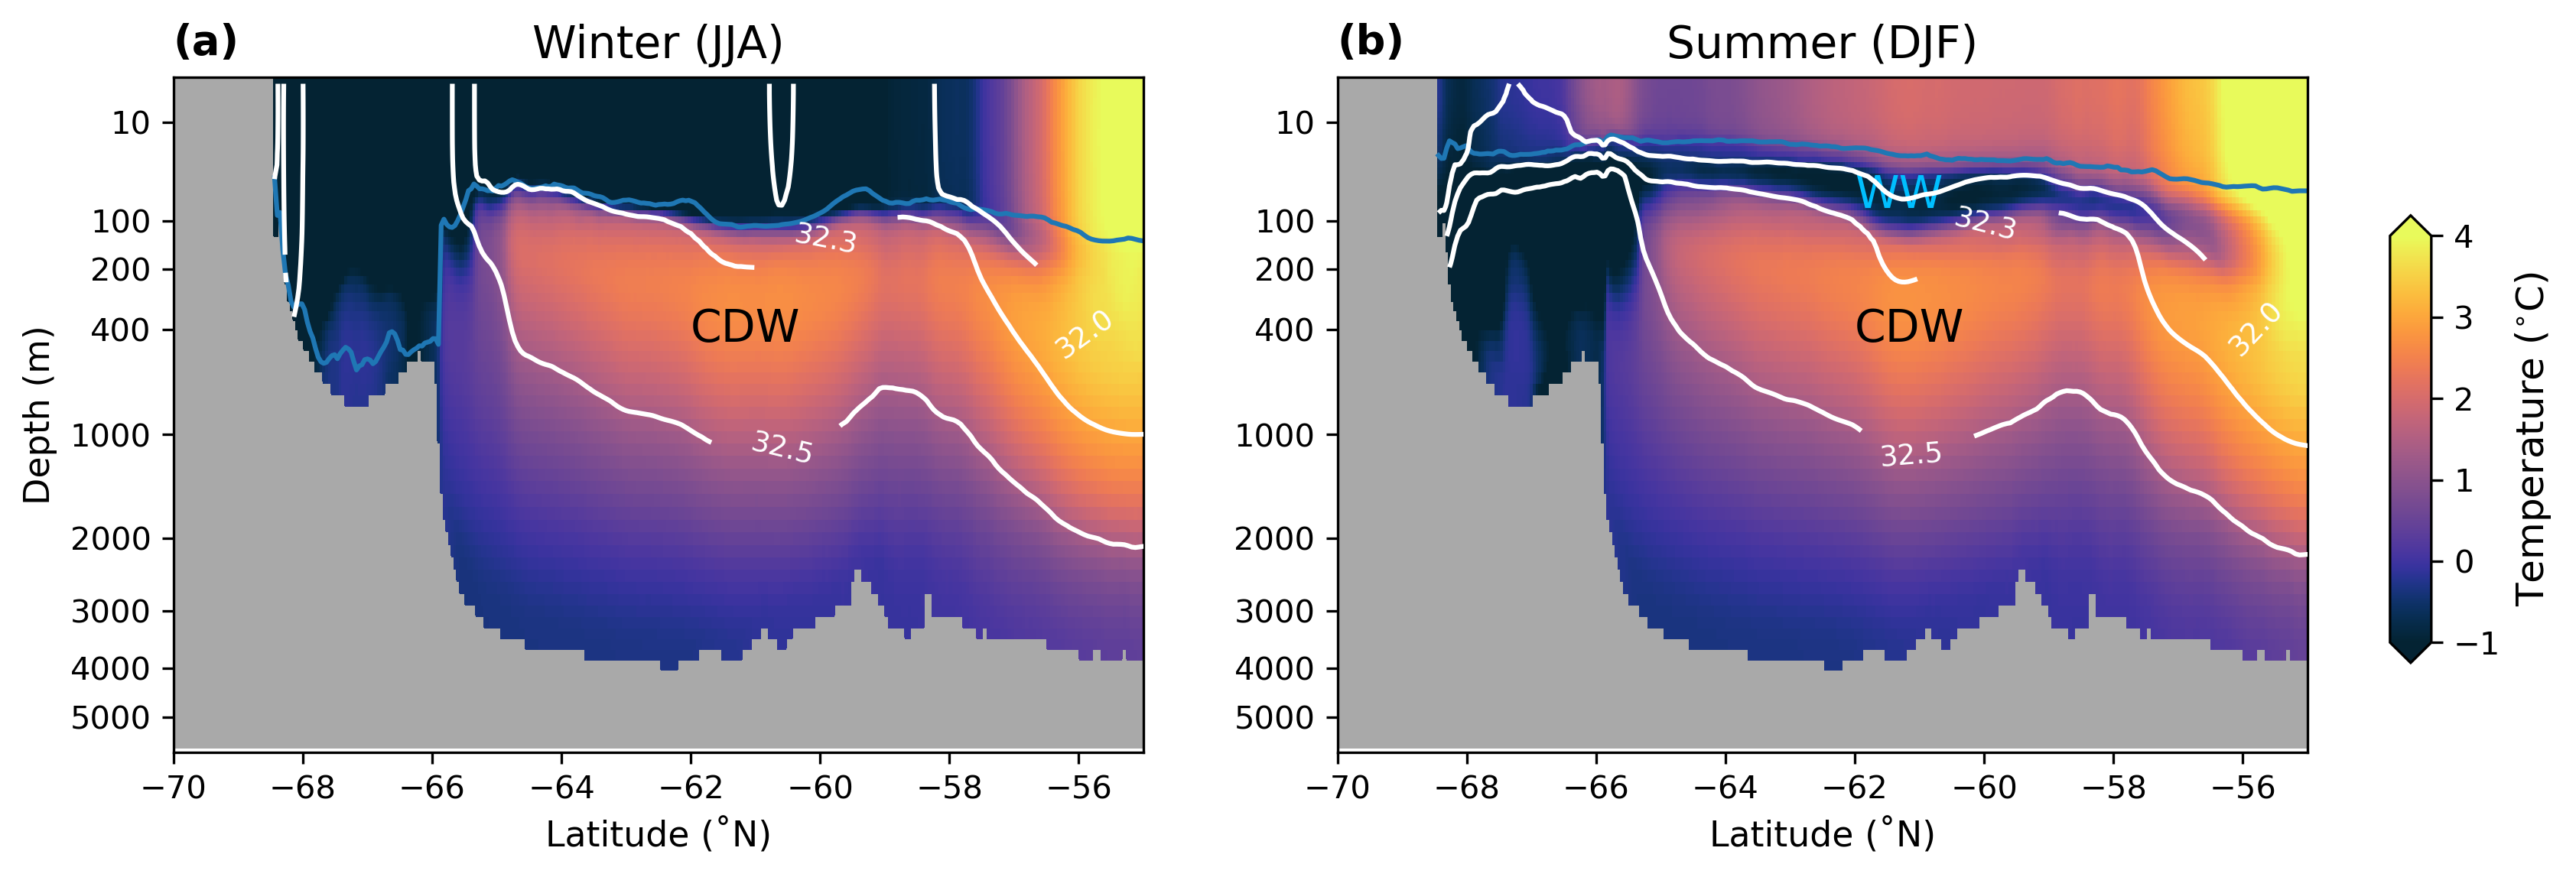

In [43]:
# Initial state of the CDW
fig = plt.figure(figsize=(12,13),dpi = 300)
projection=ccrs.SouthPolarStereo()
manual_positions1 = [
    (-60, 80), 
    (-56, 450),
    (-60,2000)
]
# transect 
ax = plt.subplot(3,2,6)
background[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p1 = (temp_summer.sel(xt_ocean = -210,method = 'nearest').sel(st_ocean = slice(1.,8000))-273.15).plot(vmin=-1,vmax=4, cmap = cm.cm.thermal,add_colorbar = False)
c2 = plt.contour(rho_ctrl_summer.sel(xt_ocean = -210,method = 'nearest').yt_ocean.values,rho_ctrl_summer[1:75,:,:].sel(xt_ocean = -210,method = 'nearest').st_ocean.values,rho_ctrl_summer.sel(xt_ocean = -210,method = 'nearest').sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='-',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions1)
plt.plot(mld_summer.yt_ocean.values,mld_summer.values)
plt.yticks([10,200,400,1000,2000,3000,4000,5000], [10,200,400,1000,2000,3000,4000,5000])  
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude (˚N)', fontsize = 11)
plt.ylabel(' ', fontsize = 11)
plt.xlim(-70,-55)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.text(-62,450,'CDW',fontsize = 14,color = 'k')
plt.text(-62,80,'WW',fontsize = 14, color = 'deepskyblue')
ax.set_title('Summer (DJF)', fontsize = 14)
ax.text(
       0.0, 1.08, '(b)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

# transect 
ax = plt.subplot(3,2,5)
background[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
p1 = (temp_winter.sel(xt_ocean = -210,method = 'nearest').sel(st_ocean = slice(1.,8000))-273.15).plot(vmin=-1,vmax=4, cmap = cm.cm.thermal,add_colorbar = False)
c2 = plt.contour(rho_ctrl_winter.sel(xt_ocean = -210,method = 'nearest').yt_ocean.values,rho_ctrl_winter[1:75,:,:].sel(xt_ocean = -210,method = 'nearest').st_ocean.values,rho_ctrl_winter.sel(xt_ocean = -210,method = 'nearest').sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='-',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions1)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
land_2[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                        add_colorbar=False)
plt.plot(mld_winter.yt_ocean.values,mld_winter.values)
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude (˚N)', fontsize = 11)

plt.ylabel('Depth (m)', fontsize = 11)
plt.xlim(-70,-55)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.text(-62,450,'CDW',fontsize = 14,color = 'k')
ax.set_title('Winter (JJA)', fontsize = 14)
ax.text(
       0.0, 1.08, '(a)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

ax_cb1 = plt.axes([0.93, 0.14, 0.015, 0.15])
cb = plt.colorbar(p1, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Temperature ($^{\circ}$C)', fontsize = 12)
cb.ax.yaxis.set_label_position('right')
cb.ax.yaxis.set_ticks_position('right')

In [44]:
new_coord = xr.open_dataarray('/scratch/x77/hm1221/nc_files/lat_to_shelf_bin.nc')

In [45]:
new_coord

<xarray.DataArray (st_ocean: 75, yt_ocean: 2700, xt_ocean: 3600)> Size: 6GB
[729000000 values with dtype=float64]
Coordinates:
  * st_ocean  (st_ocean) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.709e+03
  * yt_ocean  (yt_ocean) float64 22kB -81.11 -81.07 -81.02 ... 89.89 89.94 89.98
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95

In [46]:
background_1 = xr.DataArray(
    data=np.ones_like(temp_ctrl_mean_new),
    coords=temp_ctrl_mean_new.coords,
    dims=temp_ctrl_mean_new.dims,
    name='ones_array'
)

Text(0.0, 1.08, '(b)')

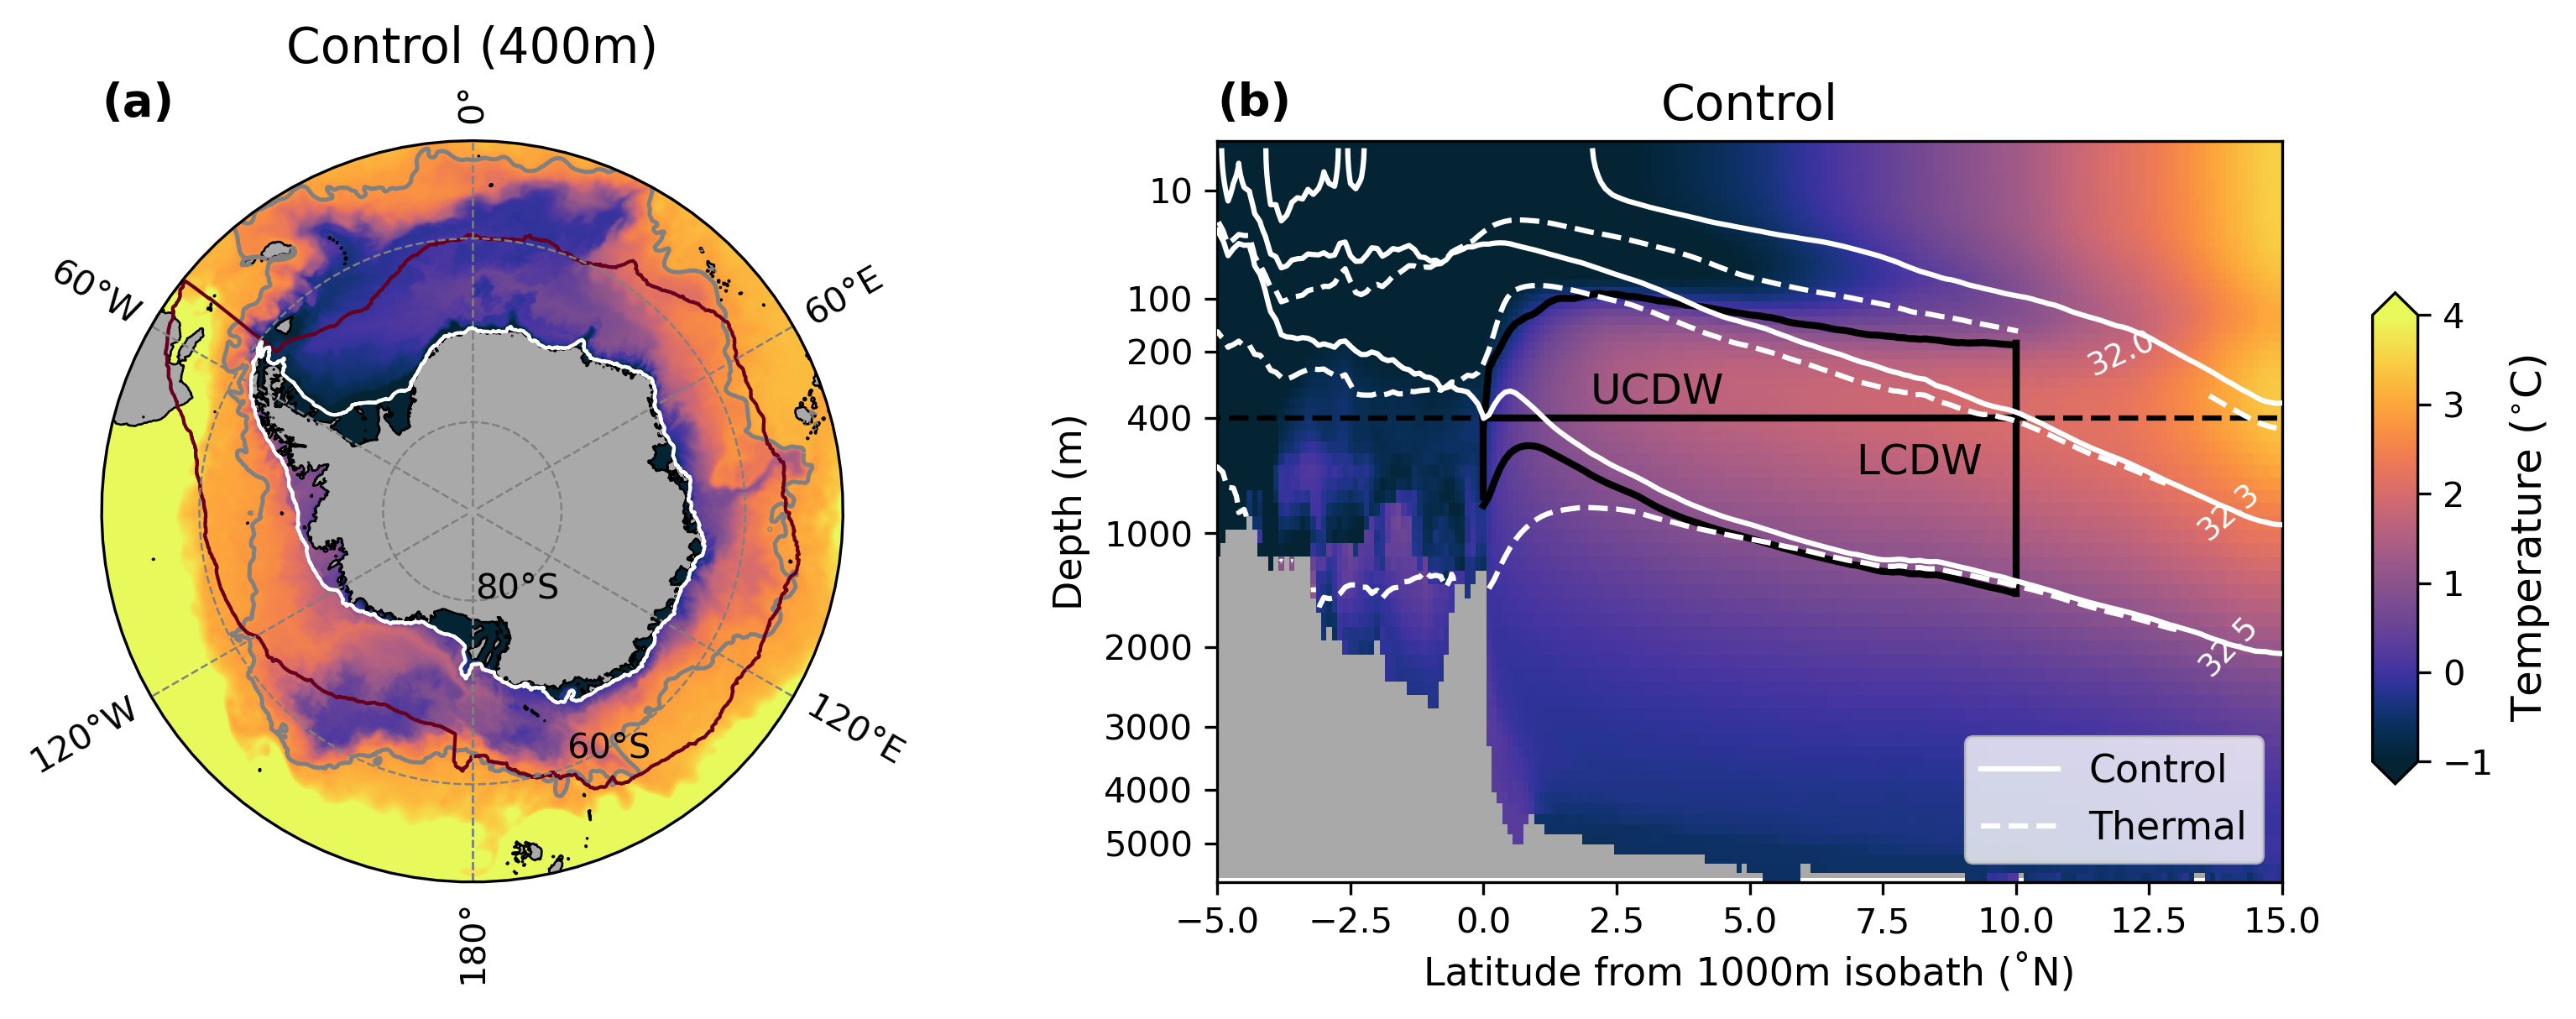

In [47]:
# Initial state of the CDW
fig = plt.figure(figsize=(12,13),dpi = 300)
projection=ccrs.SouthPolarStereo()
ax = plt.subplot(3,2,5,projection = projection,facecolor="darkgrey")
theta = np.linspace(0,2*np.pi,100)
center,radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
p1 = (data['Control']-273.15).plot(ax=ax, vmin = -1,vmax = 4, transform=ccrs.PlateCarree(),
                              cmap=cm.cm.thermal,add_colorbar = False)

land[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
land[:,:].fillna(0).plot.contour(ax=ax, colors='k', levels=[0, 1],
                            transform=ccrs.PlateCarree(), add_colorbar=False,linewidths = 0.6)
data['Control'].plot.contour(ax=ax, levels=[273.15+2.8], colors='grey', linewidths = 1.2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
new_coord[1,:666,:].plot.contour(ax=ax, levels=[10], linewidths = 1.,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
ax.text(
        0.0, 1.08, '(a)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    xlocs=np.arange(-180, 181, 60),
    ylocs=np.arange(-80, -49, 20),
    linewidth=0.6, linestyle='--', color='0.5', draw_labels=True
)
plt.plot(x_shelf, y_shelf, linewidth=1,color='white',transform=ccrs.PlateCarree())
ax.set_title('Control (400m)', fontsize = 14)
ax_cb1 = plt.axes([0.93, 0.14, 0.015, 0.15])
cb = plt.colorbar(p1, cax=ax_cb1,  orientation='vertical',extend='both')
cb.ax.set_ylabel('Temperature ($^{\circ}$C)', fontsize = 12)
cb.ax.yaxis.set_label_position('right')
cb.ax.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_ticks_position('right')
    #ax_cb2.yaxis.set_label_position('right')



# transect 
ax = plt.subplot(3,2,6)
background_1[:,:].plot.contourf(ax=ax, colors='darkgrey', zorder=0,
                        add_colorbar=False)
plt.plot(0,0,color = 'white',linestyle='-')
plt.plot(0,0,color = 'white',linestyle='--')
plt.legend(['Control','Thermal'],
           fontsize = 11,loc = 'lower right',ncol=1)
p1 = (temp_ctrl_mean_new.sel(st_ocean = slice(1.,8000))-273.15).plot(vmin=-1,vmax=4, cmap = cm.cm.thermal,add_colorbar = False)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_ctrl_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='-',linewidths=1.5,zorder=5)
c2 = plt.contour(rho_ctrl_mean_new.yt_ocean.values,rho_ctrl_mean_new[1:75,:].st_ocean.values,rho_th_mean_new.sel(st_ocean = slice(1.,8000)),levels=levs_dens,colors='white',linestyles='--',linewidths=1.5,zorder=5)
plt.clabel(c2,fontsize=9,inline=True,fmt='%1.1f',levels=levs_dens,manual = manual_positions,inline_spacing=-10)
#ax1.text(0.367,2.55,'Heat budget',fontsize = 11,color = 'k',fontweight='bold')
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
def forward(x):
    return x**(1/3)
def inverse(x):
    return x**3
plt.gca().set_yscale('function', functions=(forward, inverse))
plt.gca().invert_yaxis()
plt.xlabel('Latitude from 1000m isobath (˚N)', fontsize = 11)
plt.ylabel('Depth (m)', fontsize = 11)
plt.xlim(-5,15)
plt.yticks([10,100,200,400,1000,2000,3000,4000,5000], [10,100,200,400,1000,2000,3000,4000,5000])  
plt.plot([-10,20], [400,400], linestyle='--', color='k')
plt.plot(bound_up_mean[200:300].yt_ocean.values, bound_up_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([10,10],[180,400], c = 'k',linewidth=2)
plt.plot([0,10],[400,400], c = 'k',linewidth=2)
plt.text(2,350,'UCDW',fontsize = 12,color = 'k')
plt.text(7,650,'LCDW',fontsize = 12,color = 'k')
plt.plot(bound_low_mean[200:300].yt_ocean_sub01.values, bound_low_mean[200:300].values, c = 'k',linewidth=2)
plt.plot([10,10],[400,bound_low_mean[300].values], c = 'k',linewidth=2)
plt.plot([0,0],[400,bound_low_mean[201].values], c = 'k',linewidth=2)
#plt.ylabel(' ', fontsize = 12)
ax.set_title('Control', fontsize = 14)
ax.text(
       0.0, 1.08, '(b)', transform=ax.transAxes, fontweight='bold', 
        fontsize=13,  # Font size
        verticalalignment='top',  # Align text vertically to the top
        horizontalalignment='left',  # Align text horizontally to the left
)

In [48]:
new_coord_map = new_coord.where(new_coord<=10).where(new_coord>=0)

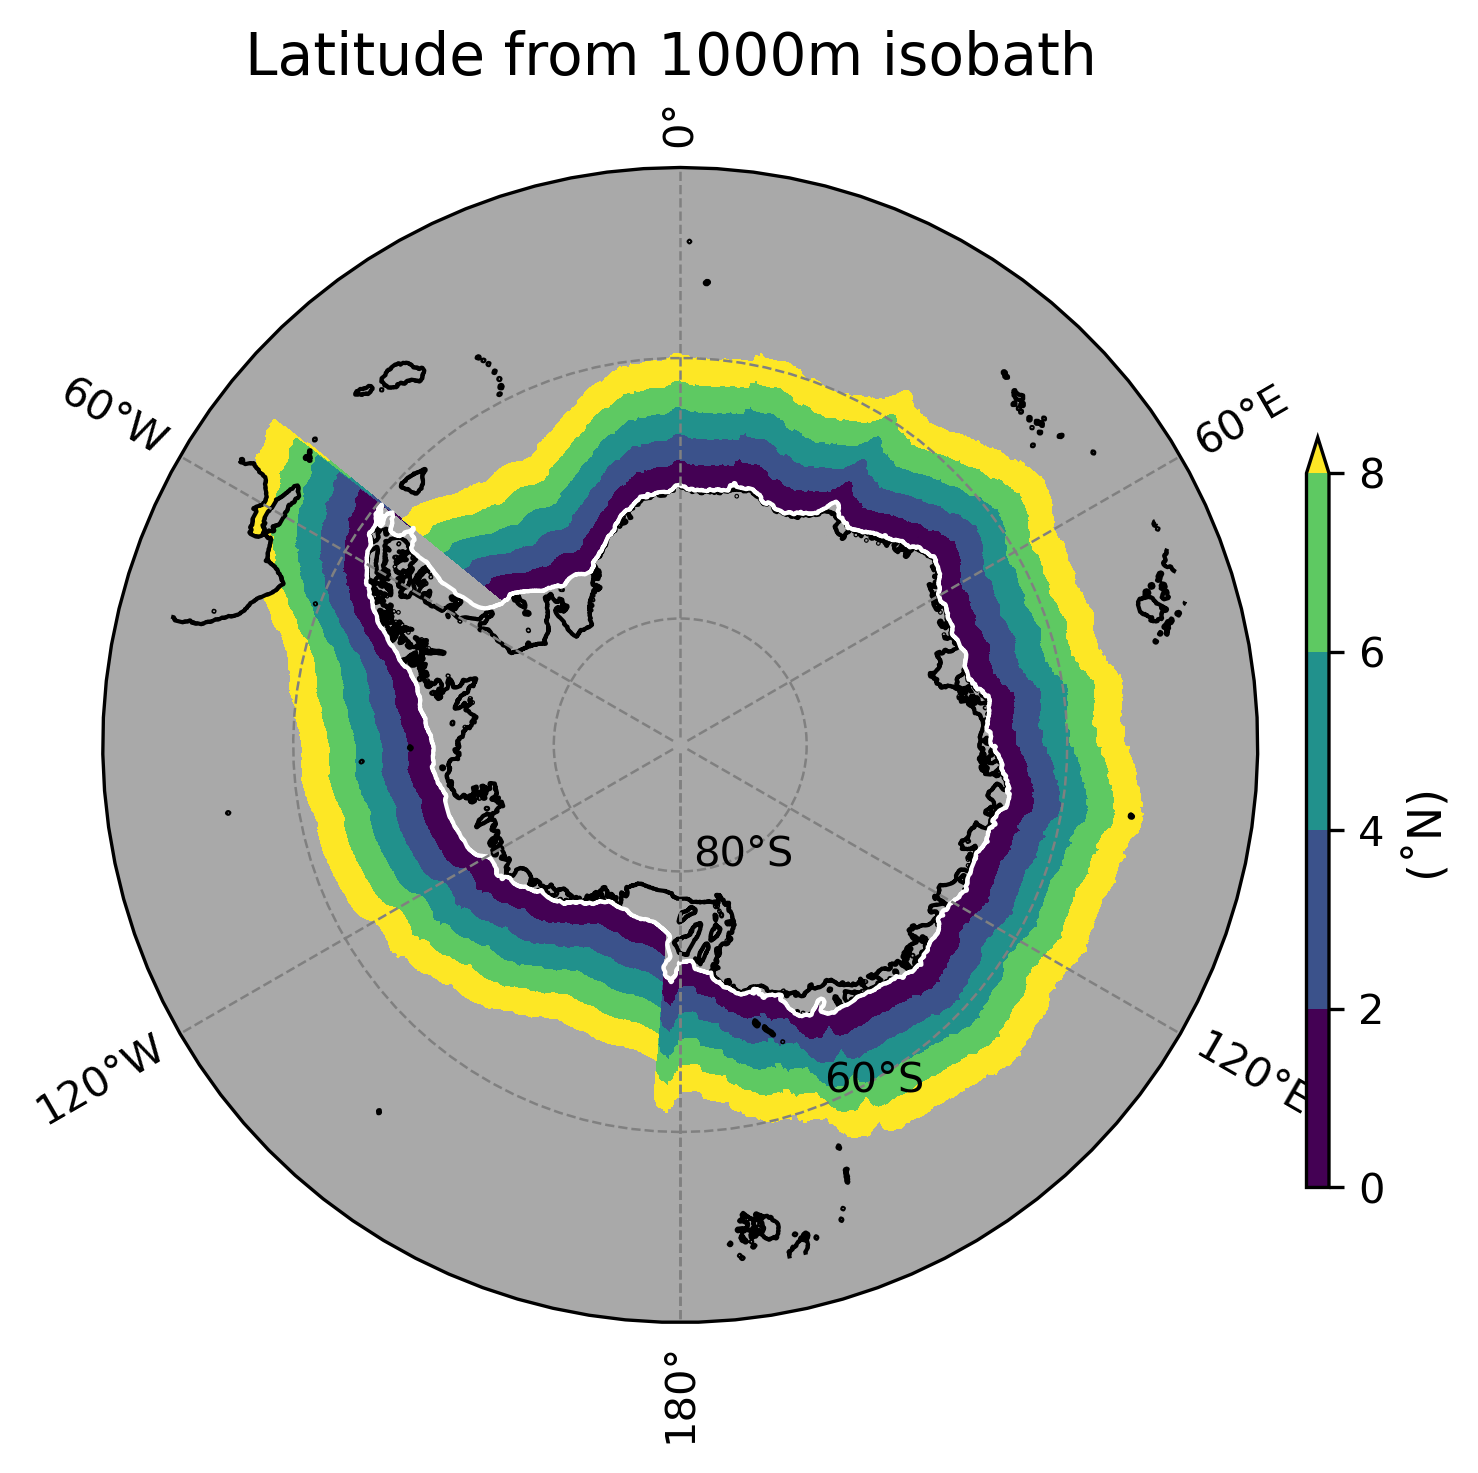

In [49]:
# For Figure S3
fig = plt.figure(figsize=(5,5),dpi = 300)
projection=ccrs.SouthPolarStereo()
ax = plt.subplot(1,1,1,projection = projection,facecolor="darkgrey")
theta = np.linspace(0,2*np.pi,100)
center,radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
p3 = new_coord_map[1,:666,:].plot.contourf(levels = np.arange(0,10,2), transform=ccrs.PlateCarree(),
                              add_colorbar = False)
#(rho_ctrl_mean[0,:,:]).plot.contour(ax=ax, levels = [32.0], transform=ccrs.PlateCarree(),
#                              linewidths = 1.,colors = 'fuchsia')
land.plot.contourf(ax=ax, colors='darkgrey', zorder=2,
                       transform=ccrs.PlateCarree(), add_colorbar=False)
land.fillna(0).plot.contour(ax=ax, colors='k', levels=[0, 1],
                            transform=ccrs.PlateCarree(), add_colorbar=False,linewidths = 1.)
#plt.scatter(x_rho, y_rho, s=0.1,color='r',transform=ccrs.PlateCarree())
plt.plot(x_shelf, y_shelf, linewidth=1,color='white',transform=ccrs.PlateCarree())
ax.set_title('Latitude from 1000m isobath ',fontsize = 14)
ax_cb2 = plt.axes([0.93, 0.2, 0.015, 0.5])
cb = plt.colorbar(p3, cax=ax_cb2,  orientation='vertical',extend='max')
cb.ax.set_ylabel('(˚N)', fontsize = 11)

gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    xlocs=np.arange(-180, 181, 60),
    ylocs=np.arange(-80, -49, 20),
    linewidth=0.6, linestyle='--', color='0.5', draw_labels=True
)